## **Assignment Supervised machine Learning - Regression**

### **_House Price Prediction Using Bolton Housing Data_**
This dataset provides information about house prices in Bolton. House Price Prediction


**In this notebook, you'll follow the basic machine learning process to build a regression model to predict house prices using the "Boston Housing Dataset" from sklearn. The regression model will either be a Decision Tree or Random Forest regressor.**



---



### **Follow the instructions and complete each TODO to complete the assessment on the essential steps in building and evaluating a regression model.**


The following is a description of each column in the dataset:

Dataset Features (Bolton Housing):

* CRIM: Crime rate by town
* ZN: Proportion of residential land zoned for large lots
* INDUS: Proportion of non-retail business acres per town
* CHAS: Charles River dummy variable (1 if tract bounds river; 0 otherwise)
* NOX: Nitric oxide concentration (parts per 10 million)
* RM: Average number of rooms per dwelling
* AGE: Proportion of owner-occupied units built before 1940
* DIS: Weighted distances to five Boston employment centers
* RAD: Index of accessibility to radial highways
* TAX: Full-value property tax rate per `$10,000`
* PTRATIO: Pupil-teacher ratio by town
* B: Proportion of Black population
* LSTAT: Percentage of lower status of the population
* MEDV (Target): Median value of owner-occupied homes in `$1,000s`



**Dataset is from sklearn Datasets**

In [6]:
#Part1: Import the relevant libraries with their aliases
# Add your imports here:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [7]:
#Part 2: Data Collection and Loading
#1.TODO: Load the 'Boston Housing' dataset and convert it into a pandas DataFrame.
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"
ca = pd.read_csv(url)

ca.columns = ca.columns.str.strip().str.upper()
ca = ca.rename(columns={"PRICE": "MEDV"})   # target: median value of owner-occupied homes

print(ca.shape)
print(ca.columns.tolist())
ca.head()

(506, 14)
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [8]:
#Part 3: Quick Check of Data
#2.TODO: Display the first few rows of the dataset to understand its structure.
# Add your code here:
ca.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [9]:
#3.TODO: Check the features and target variable. Identify which is continuous and categorical if applicable.
# Add your code here:
print(ca.info())
print(ca.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None
CRIM       float64
ZN         float64
INDUS      float64
CHAS         int64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD          int64
TAX          int64
PTRATIO    float64
B          float64
LSTAT      fl

In [12]:
#4.Quick structural check
# Count unique values per column — the key diagnostic
for col in ca.columns:
    print(f"{col:10} | unique: {ca[col].nunique():4} | dtype: {ca[col].dtype}")

ca.describe().T

CRIM       | unique:  504 | dtype: float64
ZN         | unique:   26 | dtype: float64
INDUS      | unique:   76 | dtype: float64
CHAS       | unique:    2 | dtype: int64
NOX        | unique:   81 | dtype: float64
RM         | unique:  446 | dtype: float64
AGE        | unique:  356 | dtype: float64
DIS        | unique:  412 | dtype: float64
RAD        | unique:    9 | dtype: int64
TAX        | unique:   66 | dtype: int64
PTRATIO    | unique:   46 | dtype: float64
B          | unique:  357 | dtype: float64
LSTAT      | unique:  455 | dtype: float64
MEDV       | unique:  229 | dtype: float64


,count,mean,std,min,25%,50%,75%,max
CRIM,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
ZN,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
INDUS,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
CHAS,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
NOX,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
RM,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
AGE,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
DIS,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
RAD,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
TAX,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


In [13]:
#Part 4: EDA and Data Preprocessing 
#1.TODO: Check for missing/null values.
# Add your code here:
# Null check
nulls = ca.isnull().sum()
print("Nulls per column:")
print(nulls)
print(f"\nTotal nulls: {nulls.sum()}")

# Duplicates are worth checking too
print(f"Duplicate rows: {ca.duplicated().sum()}")

# Overall structure
print(type(ca))

Nulls per column:
CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

Total nulls: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>


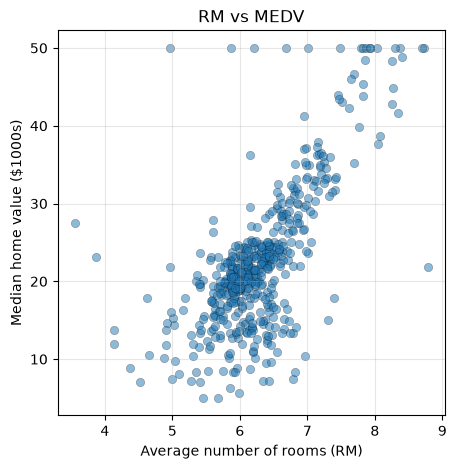

In [18]:
#Part 4: EDA and Data Preprocessing 
#2. TODO: Visualize the data. Create scatter plots to see the relationship between independent features and the target variable.
# Example: Use `plt.scatter()` to visualize the relationship between features like 'RM' (average number of rooms) and the target ('MEDV').
# Add your code here:
#Single scatter — RM vs MEDV
plt.figure(figsize=(5, 5))
plt.scatter(ca['RM'], ca['MEDV'], alpha=0.5, edgecolor='k', linewidth=0.3)
plt.xlabel('Average number of rooms (RM)')
plt.ylabel('Median home value ($1000s)')
plt.title('RM vs MEDV')
plt.grid(alpha=0.3)
plt.show()



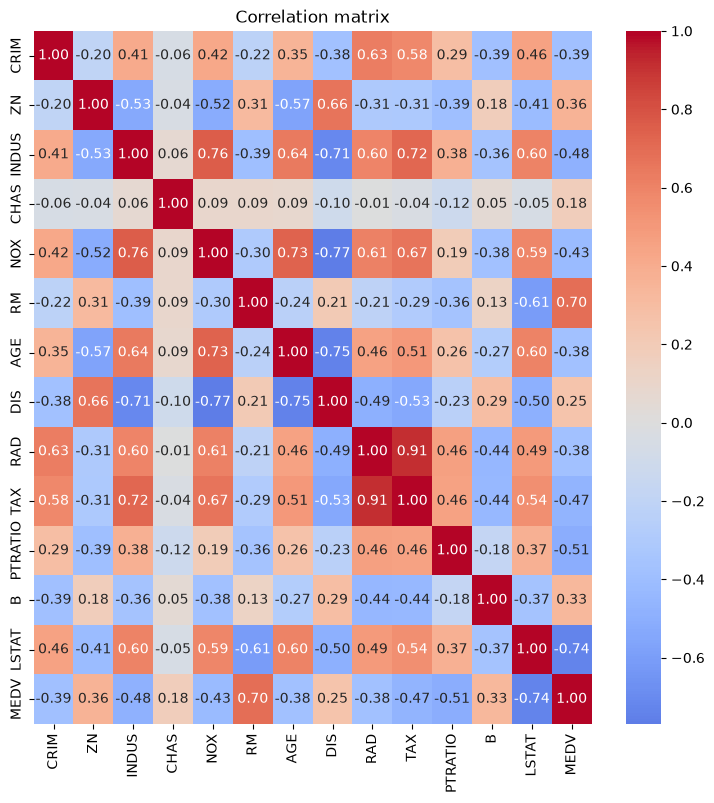

In [23]:
#Part 4: EDA and Data Preprocessing 
#3. Correlation Matrix or Confusion Matrix
plt.figure(figsize=(9, 9))
sns.heatmap(ca.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

In [28]:
#Part 4: EDA and Data Preprocessing 
#4. TODO: Create a function to automate scatter plots for all features vs the target variable.
# Define your function here:
def plot_scatter(data, features, target='MEDV'):
    n = len(features)
    rows = (n + 3) // 4

    fig, axes = plt.subplots(rows, 4, figsize=(18, 4 * rows))
    axes = axes.flatten()

    for i, col in enumerate(features):
        axes[i].scatter(ca[col], ca[target], alpha=0.4, s=12)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target)

    for j in range(n, len(axes)):
        axes[j].axis('off')

    fig.suptitle(f'Features vs {target}', fontsize=16, y=1.0)
    plt.tight_layout()
    plt.show()

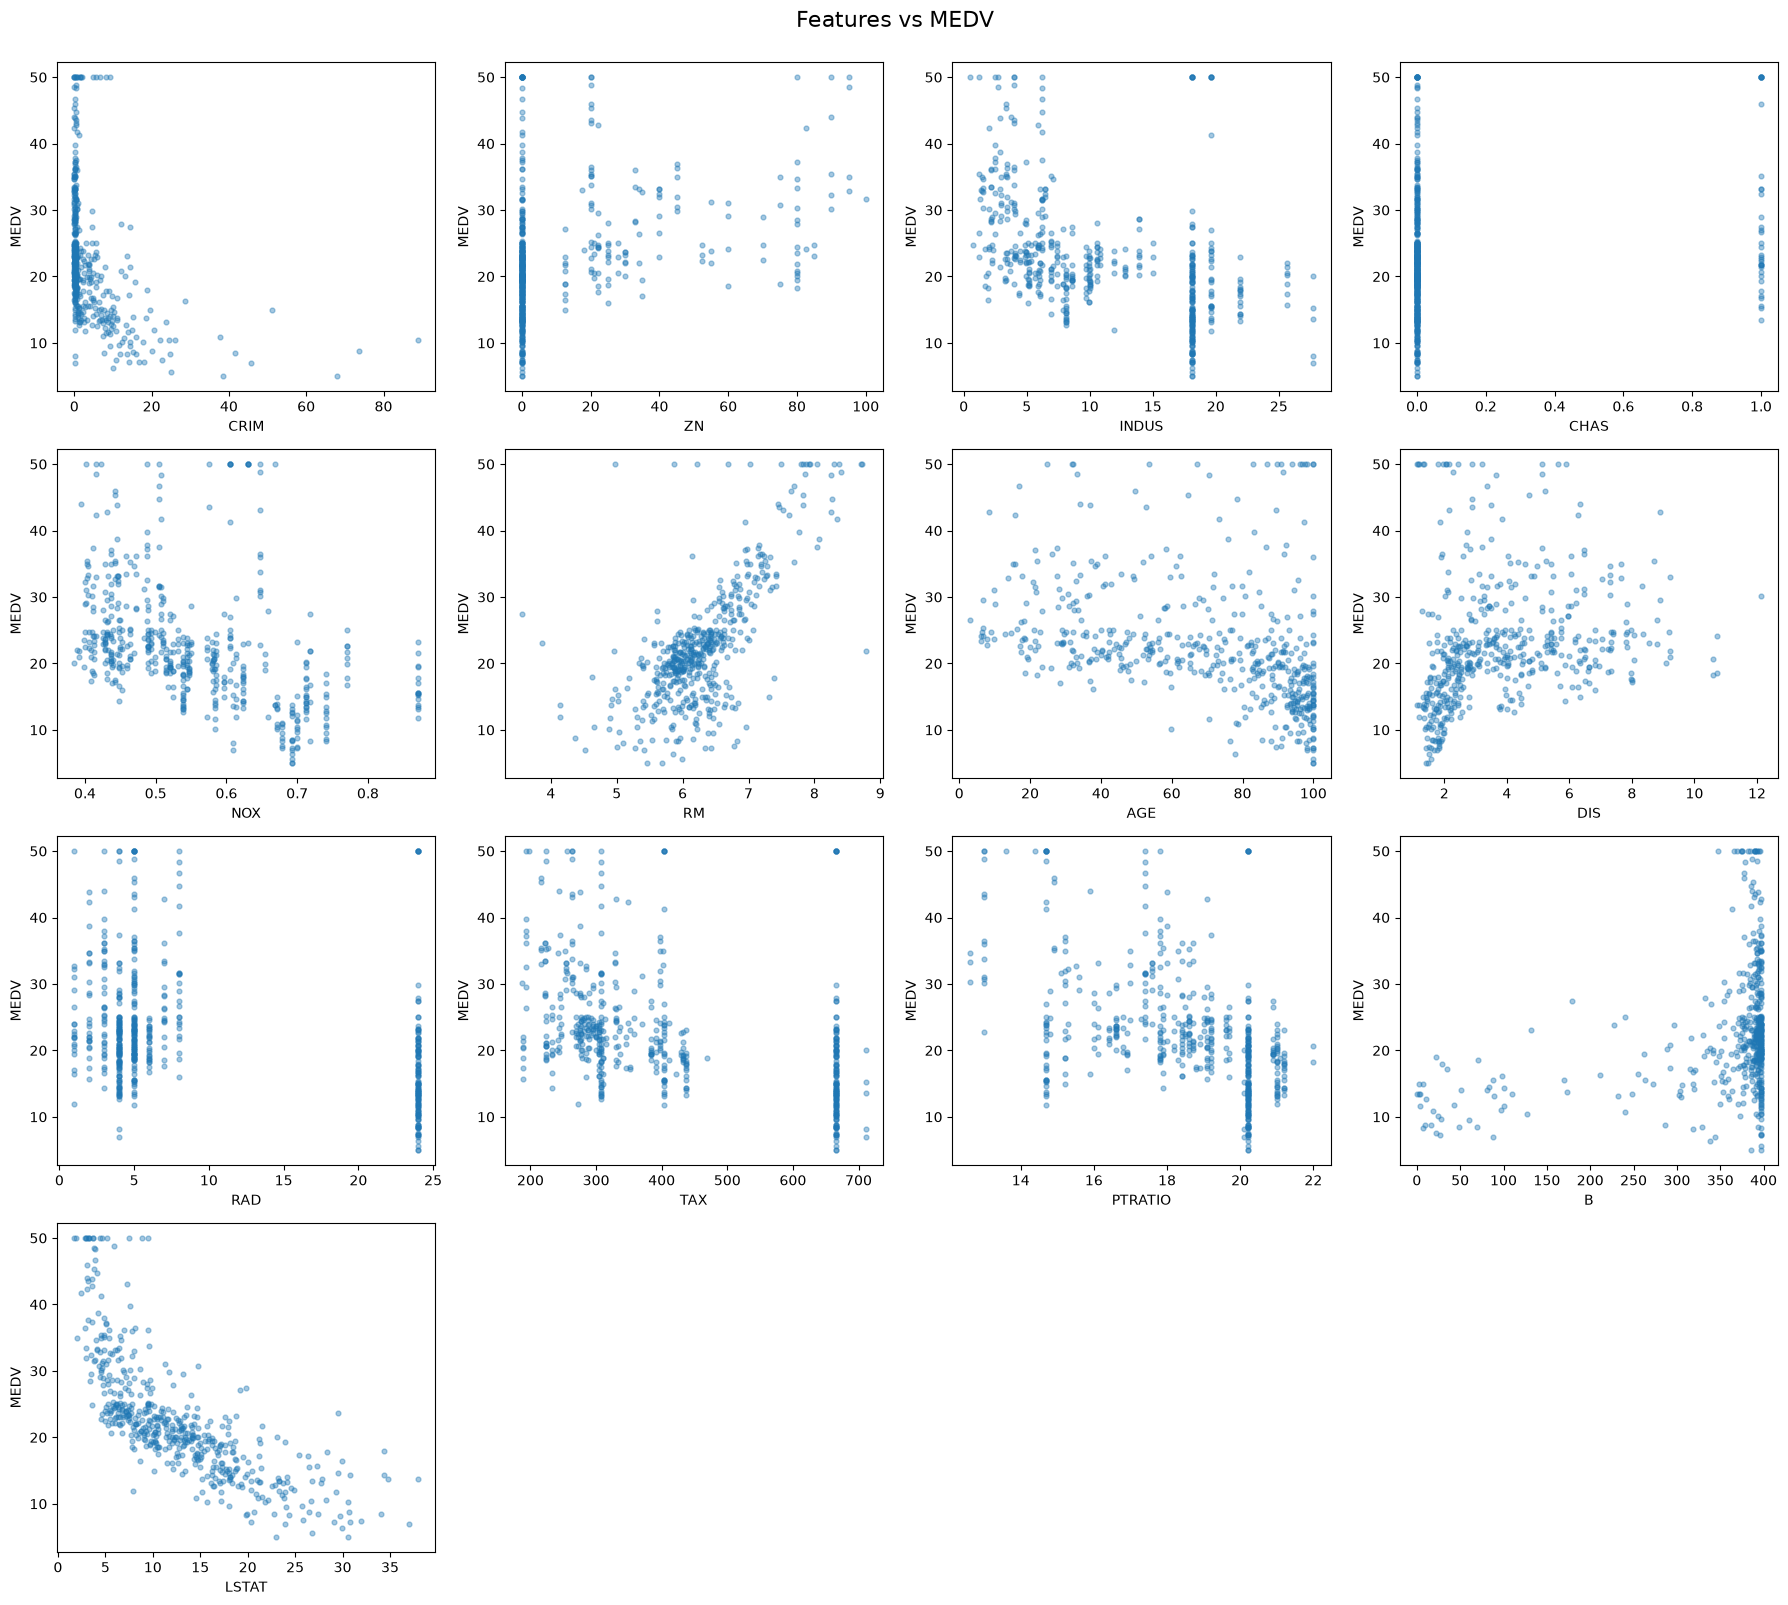

In [29]:
#Part 4: EDA and Data Preprocessing 
#5.TODO: Use the function to visualize the relationships between multiple features and the target variable.
features: ['RM', 'LSTAT', 'AGE', 'CRIM']
Target: 'MEDV'
# Add your code here:
plot_scatter(ca, features) 

In [30]:
#Part 5:  ML Model Training 
#1.TODO: Split the dataset into training and testing sets.
# Hint: Use `train_test_split()` from `sklearn.model_selection` with an 80/20 split.
# Before training, we need to create train and test Split
# Define X (features) and y (target) and perform the train-test split:
# X = independent features (everything except the target)
# y = target variable
X = ca.drop('MEDV', axis=1) #features
y = ca['MEDV'] #target

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Check the shapes
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)



X_train: (404, 13)
X_test:  (102, 13)
y_train: (404,)
y_test:  (102,)


In [31]:
X_train

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
477,15.02340,0.0,18.10,0,0.6140,5.304,97.3,2.1007,24,666,20.2,349.48,24.91
15,0.62739,0.0,8.14,0,0.5380,5.834,56.5,4.4986,4,307,21.0,395.62,8.47
332,0.03466,35.0,6.06,0,0.4379,6.031,23.3,6.6407,1,304,16.9,362.25,7.83
423,7.05042,0.0,18.10,0,0.6140,6.103,85.1,2.0218,24,666,20.2,2.52,23.29
19,0.72580,0.0,8.14,0,0.5380,5.727,69.5,3.7965,4,307,21.0,390.95,11.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...
106,0.17120,0.0,8.56,0,0.5200,5.836,91.9,2.2110,5,384,20.9,395.67,18.66
270,0.29916,20.0,6.96,0,0.4640,5.856,42.1,4.4290,3,223,18.6,388.65,13.00
348,0.01501,80.0,2.01,0,0.4350,6.635,29.7,8.3440,4,280,17.0,390.94,5.99
435,11.16040,0.0,18.10,0,0.7400,6.629,94.6,2.1247,24,666,20.2,109.85,23.27


In [32]:
y_train

477    12.0
15     19.9
332    19.4
423    13.4
19     18.2
       ... 
106    19.5
270    21.1
348    24.5
435    13.4
102    18.6
Name: MEDV, Length: 404, dtype: float64

In [33]:
X_test

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
173,0.09178,0.0,4.05,0,0.510,6.416,84.1,2.6463,5,296,16.6,395.50,9.04
274,0.05644,40.0,6.41,1,0.447,6.758,32.9,4.0776,4,254,17.6,396.90,3.53
491,0.10574,0.0,27.74,0,0.609,5.983,98.8,1.8681,4,711,20.1,390.11,18.07
72,0.09164,0.0,10.81,0,0.413,6.065,7.8,5.2873,4,305,19.2,390.91,5.52
452,5.09017,0.0,18.10,0,0.713,6.297,91.8,2.3682,24,666,20.2,385.09,17.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412,18.81100,0.0,18.10,0,0.597,4.628,100.0,1.5539,24,666,20.2,28.79,34.37
436,14.42080,0.0,18.10,0,0.740,6.461,93.3,2.0026,24,666,20.2,27.49,18.05
411,14.05070,0.0,18.10,0,0.597,6.657,100.0,1.5275,24,666,20.2,35.05,21.22
86,0.05188,0.0,4.49,0,0.449,6.015,45.1,4.4272,3,247,18.5,395.99,12.86


In [34]:
y_test

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
412    17.9
436     9.6
411    17.2
86     22.5
75     21.4
Name: MEDV, Length: 102, dtype: float64

In [35]:
#2.TODO: Choose an appropriate regression model: Decision Tree or Random Forest.
# Define your regression model here:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

#3. TODO: Train the model on the training data.
# Add your code here:
# Train and evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    results.append({
        'Model': name,
        'Train R²': r2_score(y_train, y_pred_train),
        'Test R²': r2_score(y_test, y_pred_test),
        'MAE': mean_absolute_error(y_test, y_pred_test),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_test))
    })

    print(f"{name} trained.")

# Show comparison table
results_ca = pd.DataFrame(results).round(4)
print()
print(results_ca)


Linear Regression trained.
Decision Tree trained.
Random Forest trained.

               Model  Train R²  Test R²     MAE    RMSE
0  Linear Regression    0.7509   0.6688  3.1891  4.9286
1      Decision Tree    1.0000   0.7571  2.7245  4.2209
2      Random Forest    0.9774   0.8925  2.0367  2.8072


In [36]:
#Part 6: Model Evaluation 
# TODO: Evaluate the performance of the model on the test set using relevant metrics (e.g., RMSE, R-squared).
# Perform parameter tuning on the model if needed to improve the performance of your model.
# Add your parameter tuning code here:
# Evaluate each model on the TEST set
evaluation = []

for name, model in models.items():
    y_pred = model.predict(X_test)

    evaluation.append({
        'Model': name,
        'MAE':  mean_absolute_error(y_test, y_pred),
        'MSE':  mean_squared_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²':   r2_score(y_test, y_pred)
    })

eval_df = pd.DataFrame(evaluation).round(4)
print("Model Performance on Test Set")
print(eval_df.to_string(index=False))


Model Performance on Test Set
            Model    MAE     MSE   RMSE     R²
Linear Regression 3.1891 24.2911 4.9286 0.6688
    Decision Tree 2.7245 17.8156 4.2209 0.7571
    Random Forest 2.0367  7.8802 2.8072 0.8925


In [50]:
#Part 7: Model Prediction 
#1.TODO: Predict Median value of owner-occupied homes new set of feature inputs.
#Option 1: create new data with diffents values
# new_data: CRIM = 0.2, ZN = 12.5, INDUS = 7.07, CHAS = 0, NOX = 0.5, RM = 6.5, AGE = 68, DIS = 4.0, 
# RAD = 2, TAX = 250, PTRATIO = 17, B = 400, LSTAT = 12
# Add your prediction code here: 
new_data= pd.DataFrame([{
    'CRIM': 0.2,
    'ZN': 12.5,
    'INDUS': 7.07,
    'CHAS': 0,
    'NOX': 0.5,
    'RM': 6.5,
    'AGE': 68,
    'DIS': 4.0,
    'RAD': 2,
    'TAX': 250,
    'PTRATIO': 17,
    'B': 400,
    'LSTAT': 12
}])

In [52]:

# 2. Match the training column order exactly
new_data = new_data[X_train.columns]
print(new_data)

# 3. Predict
prediction = model.predict(new_data)
print(f"\nPredicted median home value: ${prediction[0] * 10000:,.2f}")

   CRIM    ZN  INDUS  CHAS  NOX   RM  AGE  DIS  RAD  TAX  PTRATIO    B  LSTAT
0   0.2  12.5   7.07     0  0.5  6.5   68  4.0    2  250       17  400     12

Predicted median home value: $222,070.00


The prediction about the median home values is $222,070.00

In [55]:
#Part 7: Model Prediction:
#Randomly values
rng = np.random.default_rng(42)   # remove the seed for different values each run

# Draw each feature uniformly between its own min and max in the dataset
random_data = pd.DataFrame([{col: rng.uniform(ca[col].min(), ca[col].max()) for col in X_train.columns}])

# CHAS is binary and RAD is an index — round them back to valid values
random_data['CHAS'] = rng.integers(0, 2)
random_data['RAD'] = rng.choice(ca['RAD'].unique())

random_data = random_data[X_train.columns]
print(random_data.T)

prediction = model.predict(random_data)
print(f"\nPredicted median home value: ${prediction[0] * 1000:,.2f}")

                  0
CRIM      68.865097
ZN        43.887844
INDUS     23.882551
CHAS       0.000000
NOX        0.430770
RM         8.652773
AGE       76.806665
DIS        9.773871
RAD        7.000000
TAX      423.002231
PTRATIO   16.085501
B        367.856459
LSTAT     25.063672

Predicted median home value: $35,988.00


Interpretation:
Two prediction approaches were tested. The first used a deliberately chosen set of feature values representing a typical house. The second generated values randomly within each feature's observed minimum and maximum.

The predictions from the random inputs showed noticeably higher variability. This is expected: random sampling treats each feature independently, so it can produce combinations that never occur in reality, for example, a high average room count paired with a high percentage of lower-status population. Because the model was never trained on such combinations, its predictions in those regions are less reliable.

The purposely selected input, by contrast, reflected a realistic combination of features and produced a prediction consistent with the patterns seen during training.